Now, could you also extract the following information from ALL the jobs posted in the last 24 hours, on top of the information you have already obtained? 
- Date and Time of posting
- plot a graph of number of jobs against time of day (hour). Export this in .png
- For the fulltime/parttime classification, could you clean the unnecessary text
away?
- Get the URL of the company. At this step, try figuring out how to spot mycareerfuture. You will likely only notice this when using Selenium.
- Get the job classification and sub-classification

# Beautiful Soup

Import libraries

In [23]:
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import re

job_list = []

# Clean the job type text (e.g., "This is a Full-time job" becomes "Full-time")
def clean_job_type(job_type_text):
    job_type_cleaned = re.sub(r'This is a (.*) job', r'\1', job_type_text)
    return job_type_cleaned.strip()

# Remove parentheses from job classification string
def remove_parentheses(s):
    if s.startswith('(') and s.endswith(')'):
        return s[1:-1]
    return s

# Function to convert relative time to absolute datetime
def parse_relative_time(relative_time):
    current_time = datetime.now()
    
    if "m ago" in relative_time:
        minutes_ago = int(relative_time.replace("m ago", "").strip())
        return current_time - timedelta(minutes=minutes_ago)
    elif "h ago" in relative_time:
        hours_ago = int(relative_time.replace("h ago", "").strip())
        return current_time - timedelta(hours=hours_ago)
    else:
        return None  # We don't handle "days ago" or "weeks ago" now

# Extract job data from the page
def get_jobs_from_page(page_num):
    URL = f"https://sg.jobstreet.com/jobs?page={page_num}&sortmode=ListedDate"
    page = requests.get(URL)
    soup = BeautifulSoup(page.content, "html.parser")
    job_list = []
    job_cards = soup.find_all(attrs={"data-testid": "job-card"})
    
    for job in job_cards:
        job_title_text = job.get('aria-label')
        job_id = job.get('data-job-id')

        company_tag = job.find(attrs={'data-automation': 'jobCompany'})
        company_name_text = company_tag.text.strip() if company_tag else 'N/A'

        salary_tag = job.find(attrs={'data-automation': 'jobSalary'})
        salary_range = salary_tag.text.strip() if salary_tag else 'N/A'

        job_type_tag = job.find('p')
        job_type = job_type_tag.text.strip() if job_type_tag else 'N/A'
        job_type = clean_job_type(job_type)

        location_tags = job.find_all(attrs={'data-automation': 'jobCardLocation'})
        job_locations = [loc.get_text(strip=True) for loc in location_tags]

        classification_tag = job.find(attrs={'data-automation': 'jobClassification'})
        job_classification = classification_tag.text.strip() if classification_tag else 'N/A'
        job_classification = remove_parentheses(job_classification)

        subclassification_tag = job.find(attrs={'data-automation': 'jobSubClassification'})
        job_subclassification = subclassification_tag.text.strip() if subclassification_tag else 'N/A'
    

        listing_date_tag = job.find(attrs={'data-automation': 'jobListingDate'})
        listing_date = listing_date_tag.text.strip() if listing_date_tag else 'N/A'

        # Convert relative time to actual datetime
        post_datetime = parse_relative_time(listing_date)
        
        # Only consider jobs posted within the last 24 hours
        if post_datetime and post_datetime >= datetime.now() - timedelta(days=1):
            

            job_list.append({
                'Job Title': job_title_text,
                'Job ID': job_id,
                'Company': company_name_text,
                'Salary Range': salary_range,
                'Job Type': job_type,
                'Job Locations': job_locations,
                'Job Classification': job_classification,
                'Job Sub Classification': job_subclassification,
                'Listing Time Since': listing_date,
                'Actual Posted DateTime': post_datetime
            })
            
    return job_list



In [24]:
# Main loop to scrape all jobs within 24 hours
page_num = 1
while True:
    jobs = get_jobs_from_page(page_num)
    
    if not jobs:
        print("No more jobs found on this page.")
        break
    
    job_list.extend(jobs)
    page_num += 1

No more jobs found on this page.


In [25]:
# Convert the list of jobs to a DataFrame
df = pd.DataFrame(job_list)

# Check how many jobs were fetched
print(f"Fetched {len(df)} jobs in the last 24 hours")

df.head(5)

Fetched 2280 jobs in the last 24 hours


,Job Title,Job ID,Company,Salary Range,Job Type,Job Locations,Job Classification,Job Sub Classification,Listing Time Since,Actual Posted DateTime
0,Creative Art Designer (1 year contract) - Ecom...,82785872,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,200 – $3,800 per month",Contract/Temp,[Central Region],Design & Architecture,Graphic Design,3m ago,2025-03-14 21:58:27.552516
1,Customer Care Officer (Pivot Table) - Toa Payo...,82785867,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$2,500 – $3,000 per month",Full time,[Central Region],Call Centre & Customer Service,Customer Service - Call Centre,4m ago,2025-03-14 21:57:27.552516
2,Call Centre (Insurance Industry) - 1 year cont...,82785866,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,000 – $3,800 per month",Contract/Temp,[East Region],Call Centre & Customer Service,Customer Service - Call Centre,5m ago,2025-03-14 21:56:27.552516
3,Finance Executive (AP Shared Services),82785860,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,500 – $4,000 per month",Contract/Temp,[West Region],Accounting,Accounts Payable,9m ago,2025-03-14 21:52:27.552516
4,Live Chat Agent (1 year contract) - Eunos - Up...,82785853,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,000 – $3,800 per month",Contract/Temp,[East Region],Call Centre & Customer Service,Customer Service - Call Centre,11m ago,2025-03-14 21:50:27.552516


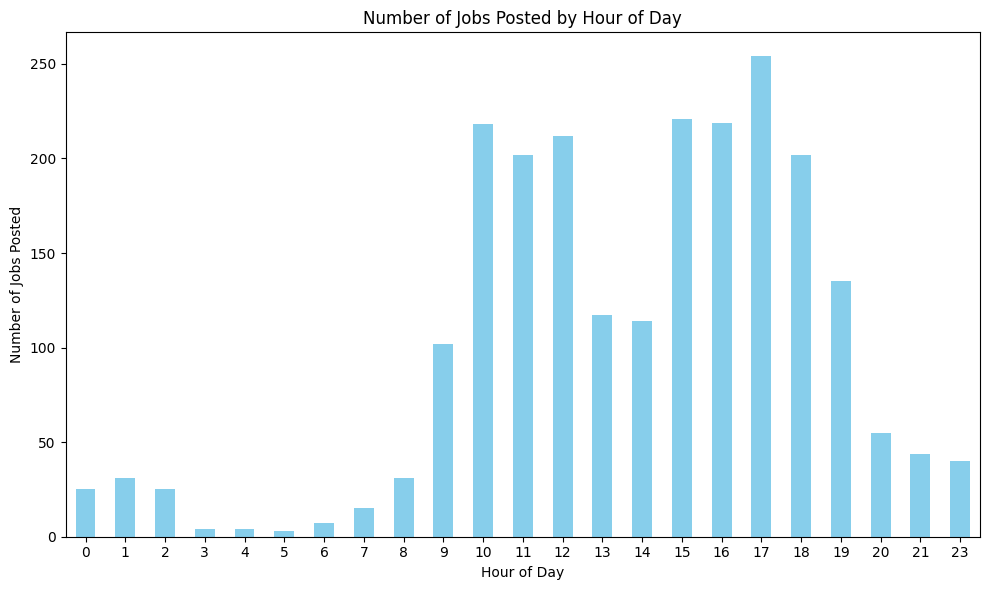

In [26]:
# Plot the number of jobs posted by hour of the day
df['Hour Posted'] = df['Actual Posted DateTime'].dt.hour
hourly_jobs = df.groupby('Hour Posted').size()

plt.figure(figsize=(10, 6))
hourly_jobs.plot(kind='bar', color='skyblue')
plt.title('Number of Jobs Posted by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Jobs Posted')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cyx_bar_graph_of_job_postings_by_hour.png')

In [27]:
# Export data to Excel
df.to_excel('cyx_jobstreet_jobs_last_24_hours.xlsx', index=False)

# Selenium

import libraries

In [17]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import time
import pandas as pd
import re
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Setup Selenium WebDriver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

In [ ]:
# Clean the job type text (e.g., "This is a Full-time job" becomes "Full-time")
def clean_job_type(job_type_text):
    job_type_cleaned = re.sub(r'This is a (.*) job', r'\1', job_type_text)
    return job_type_cleaned.strip()

# Remove parentheses from job classification string
def remove_parentheses(s):
    if s.startswith('(') and s.endswith(')'):
        return s[1:-1]
    return s

# Function to convert relative time to absolute datetime
def parse_relative_time(relative_time):
    current_time = datetime.now()
    
    if "m ago" in relative_time:
        minutes_ago = int(relative_time.replace("m ago", "").strip())
        return current_time - timedelta(minutes=minutes_ago)
    elif "h ago" in relative_time:
        hours_ago = int(relative_time.replace("h ago", "").strip())
        return current_time - timedelta(hours=hours_ago)
    else:
        return None  # We don't handle "days ago" or "weeks ago" now
    
job_list = []

# Extract job data from the page
def get_jobs_from_page(page_num):
    URL = f"https://sg.jobstreet.com/jobs?page={page_num}&sortmode=ListedDate"
    
    # Open the webpage with Selenium
    driver.get(URL)
    
    # Give the page some time to load (you can use WebDriverWait for a more efficient wait)
    time.sleep(3)
    
    # Find all the job cards on the page
    job_list = []
    job_cards = driver.find_elements(By.CSS_SELECTOR, '[data-testid="job-card"]')
    
    # Extract information for each job card
    for job in job_cards:
        # Extract job title
        job_title_text = job.get_attribute('aria-label')
        
        # Extract job ID
        job_id = job.get_attribute('data-job-id')
        
        # Extract company name
        company_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobCompany"]')
        company_name_text = company_tag.text.strip() if company_tag else 'N/A'
        
        # Extract the href attribute (company URL)
        company_href = company_tag.get_attribute('href')
        
        # Check if company_href starts with /jobs?advertiserid= and has rel="nofollow"
        if company_href and company_href.startswith('/jobs?advertiserid=') and 'rel="nofollow"' in company_tag.get_attribute('outerHTML'):
            continue  # Skip this job as it matches the unwanted pattern


        # Extract salary range
        salary_tag = WebDriverWait(driver, 10).until(
             EC.presence_of_element_located((By.CSS_SELECTOR, '[data-automation="jobSalary"]'))
             )
        salary_range = salary_tag.text.strip() if salary_tag else 'N/A'
        
        # Extract the job URL
        url_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="job-list-view-job-link"]')
        full_job_url = url_tag.get_attribute('href') if url_tag else 'N/A'

        
        # Extract Job Type or brief description
        job_type_tag = job.find_element(By.TAG_NAME, 'p')
        job_type = job_type_tag.text.strip() if job_type_tag else 'N/A'
        job_type = clean_job_type(job_type)
        
        # Extract Job Locations
        location_tags = job.find_elements(By.CSS_SELECTOR, '[data-automation="jobCardLocation"]')
        job_locations = [loc.text.strip() for loc in location_tags]

        # Extract Job Classification
        classification_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobClassification"]')
        job_classification = classification_tag.text.strip() if classification_tag else 'N/A'
        job_classification = remove_parentheses(job_classification)
        
        # Extract Job Sub-Classification
        subclassification_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobSubClassification"]')
        job_subclassification = subclassification_tag.text.strip() if subclassification_tag else 'N/A'

        
        # Extract Listing Date
        listing_date_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobListingDate"]')
        listing_date = listing_date_tag.text.strip() if listing_date_tag else 'N/A'

        # Convert relative time to actual datetime
        post_datetime = parse_relative_time(listing_date)
        
        # Only consider jobs posted within the last 24 hours
        if post_datetime and post_datetime >= datetime.now() - timedelta(days=1):
            
            # Append the job data to the list
            job_list.append({
                'Job Title': job_title_text,
                'Job ID': job_id,
                'URL': full_job_url,
                'Company': company_name_text,
                'Salary Range': salary_range,
                'Job Type': job_type,
                'Job Locations': job_locations,                
                'Job Classification': job_classification,
                'Job Sub Classification': job_subclassification,
                'Listing Time Since': listing_date,
                'Actual Posted DateTime': post_datetime
            })
    
    return job_list


In [19]:
# Main loop to scrape all jobs within 24 hours
page_num = 1
while True:
    jobs = get_jobs_from_page(page_num)
    
    if not jobs:
        print("No more jobs found on this page.")
        break
    
    job_list.extend(jobs)
    page_num += 1

No more jobs found on this page.


In [20]:
# Create a DataFrame from the collected job data
df = pd.DataFrame(job_list)

# Check how many jobs were fetched
print(f"Fetched {len(df)} jobs in the last 24 hours")

df.head(5)


Fetched 2284 jobs in the last 24 hours


,Job Title,Job ID,URL,Company,Salary Range,Job Type,Job Locations,Job Classification,Job Sub Classification,Listing Time Since,Actual Posted DateTime
0,Learning & Development Engagement Officer (6 m...,82785841,https://sg.jobstreet.com/job/82785841?type=sta...,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,500 – $3,800 per month",Contract/Temp,[Central Region],Human Resources & Recruitment,Training & Development,5m ago,2025-03-14 21:43:47.208976
1,Junior Sales Manager - Service Contracts Asia ...,82785838,https://sg.jobstreet.com/job/82785838?type=sta...,MAN Energy Solutions Singapore Pte. Ltd.,"$3,500 – $3,800 per month",Full time,"[Tuas, , West Region]",Sales,New Business Development,6m ago,2025-03-14 21:42:47.308771
2,Customer Service (Attend Walk-ins) - 1 year co...,82785837,https://sg.jobstreet.com/job/82785837?type=sta...,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,500 – $3,800 per month",Contract/Temp,[East Region],Call Centre & Customer Service,Customer Service - Call Centre,7m ago,2025-03-14 21:41:47.414479
3,QA Validation Specialist (Pharma),82785831,https://sg.jobstreet.com/job/82785831?type=sta...,Manpower Staffing Services (S) Pte Ltd - Head ...,"$3,500 – $3,800 per month",Contract/Temp,"[Tuas, , West Region]",Science & Technology,Quality Assurance & Control,11m ago,2025-03-14 21:37:47.578092
4,Junior Creative Art Designer (1 + 1 year contr...,82785826,https://sg.jobstreet.com/job/82785826?type=sta...,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,500 – $3,800 per month",Contract/Temp,[Central Region],Design & Architecture,Graphic Design,13m ago,2025-03-14 21:35:47.675431


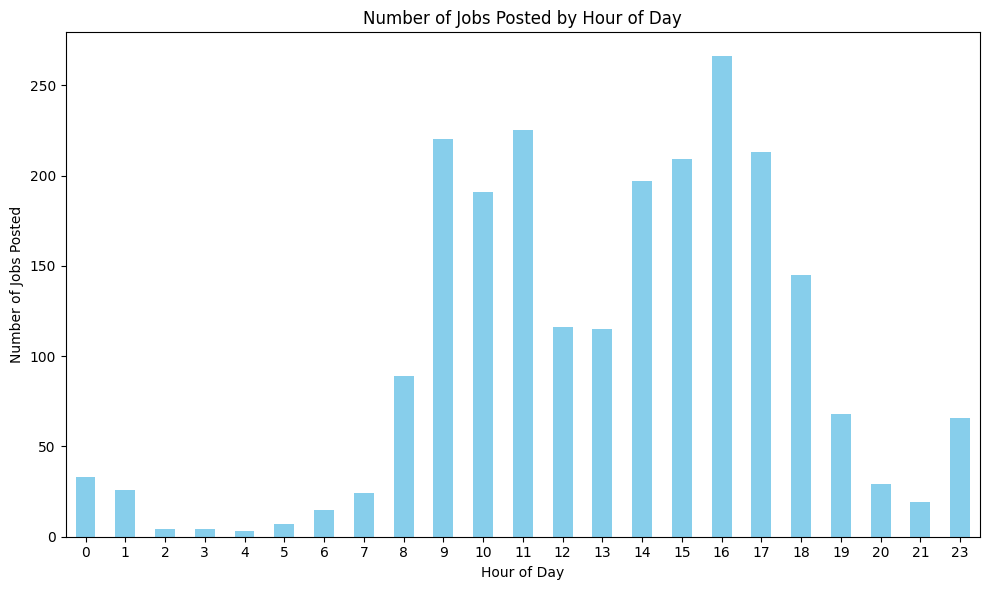

In [21]:
# Plot the number of jobs posted by hour of the day
df['Hour Posted'] = df['Actual Posted DateTime'].dt.hour  # Extract hour from datetime
hourly_jobs = df.groupby('Hour Posted').size()

plt.figure(figsize=(10, 6))
hourly_jobs.plot(kind='bar', color='skyblue')
plt.title('Number of Jobs Posted by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Jobs Posted')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('job_postings_by_hour_selenium.png')


In [ ]:
# Export data to Excel
df.to_excel('cyx_jobstreet_jobs_last_24_hours_selenium.xlsx', index=False)